**Inclass: Practical Statistics**
    
- Part of Data Science in Python Specialization for PT Freeport Indonesia
- Course Length: 12 Hours
- Last Updated: September 2025

---

Developed by [Algoritma](https://algorit.ma/)'s product division and instructors team

# Training Objectives

* **Descriptive Statistics**
    * **Measure of Central Tendency**
        - Mean 
        - Median
        - Mode
    * **Measure of Spread**
        - Standard Deviation
        - Variance
        - Boxplot
    * **Variable Relationship**
        - Covariance
        - Correlation
        - Scatter plot
* **Inferential Statistics**
    * **Probability Concept**
        - Normal distribution
        - Probability density function
        - Probability mass function
    * **Estimation & Confidence Interfal**
        - Central Limit Theorem (CLT)
        - Standard error and confidence interval
    * **Hypothesis Testing**
        + Z-test
        + T-test
        + ANOVA (Analysis of Variance)
        + Post Hoc Test

# Environment Preparation

Berbeda dengan sebelumnya dimana instalasi library dilakukan satu per satu, sekarang kita akan menggunakan file **`requirements.txt`**. File ini berisi daftar library Python yang diperlukan agar project dapat berjalan dengan benar. 

Untuk melakukan instalasi, pastikan Anda sudah berada pada direktori project, kemudian jalankan perintah berikut:

```py
%pip install -r requirements.txt
```

In [1]:
# code here
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Practical Statistics

Practical Statistics merupakan salah satu bagian penting dalam pengolahan data sehingga mendukung *business case* yang ingin diangkat. Practical Statistics berisi kaidah statistika yang banyak diterapkan dalam praktik data science agar dapat **memahami dan mengolah data dengan tepat**. 

Secara umum, Practical Statistics terbagi 2, masing-masing membantu kita dalam hal tertentu:

* **Descriptive Statistics**: meringkas informasi dalam data agar terambil insight secara cepat. Nilai-nilai yang didapatkan merupakan rangkuman dari data, tujuannya untuk menggambarkan keadaan data secara umum.

* **Inferential Statistics**: menyimpulkan sesuatu tentang kondisi di lapangan, berdasarkan data yang kita punya (sample -> population).


<img src="assets/PS.png" width="1000">

Untuk lebih memahami *practical statistics*, mari kita melakukan analisis menggunakan data asli.

In [2]:
import pandas as pd
import numpy as np #perhitungan statistik
import matplotlib.pyplot as plt # untuk visualisasi
import math # perhitungan statistik
from scipy import stats #untuk perhitungan statistik
import seaborn as sns # untuk visualisasi

pd.set_option('display.float_format', '{:.2f}'.format) # suppress scientific notation

# Study Case: New York Natural Gas & Oil Production

Dataset ini berisi informasi produksi dari sumur minyak dan gas di Negara Bagian New York dari tahun 1967 hingga 1999. Setiap record/baris mewakili jumlah berdasarkan operator untuk setiap pengelompokan county (wilayah), kota, dan ladang (field).

In [3]:
newyork = pd.read_csv('data_input/New_York_Oil_and_Gas_1967-1999.csv')
newyork.head()

,Production Year,Production Date Entered,Operator,County,Town,Field,Producing Formation,Active Oil Wells,Inactive Oil Wells,Active Gas Wells,Inactive Gas Wells,Injection Wells,Disposal Wells,Self-use Well,"Oil Produced, bbl","Gas Produced, Mcf","Water produced, bbl","Taxable Gas, Mcf",Purchaser Codes,Location
0,1983,1984-02-01,"Resource Exploration, Inc.",Chautauqua,NORTH HARMONY,NORTH HARMONY,BASS ISLAND,3,4,1,0,0,0,NO,14611,32962,0,0,NaN,"NORTH HARMONY, NY\n(42.094296, -79.374999)"
1,1983,1984-02-01,F & T Oil,Chautauqua,BUSTI,BUSTI,GLADE,1,0,0,0,0,0,NO,109,52,30,0,NaN,"BUSTI, NY\n(42.038067, -79.283549)"
2,1983,1984-02-07,Pennzoil Products Co.,Cattaraugus,CARROLLTON,CHIPMUNK,CHIPMUNK,366,24,0,0,297,0,NO,44040,678,1085208,0,NaN,"CARROLLTON, NY\n(42.023289, -78.628438)"
3,1983,1984-02-07,Pennzoil Products Co.,Cattaraugus,ALLEGANY,CHIPMUNK,CHIPMUNK,329,4,0,0,317,0,NO,57183,863,1382784,0,NaN,"ALLEGANY, NY\n(42.088061, -78.491258)"
4,1983,1984-02-07,Pennzoil Products Co.,Cattaraugus,ALLEGANY,BRADFORD,BRADFORD,167,33,0,0,167,0,NO,114238,1745,2328360,0,NaN,"ALLEGANY, NY\n(42.088061, -78.491258)"


**Deskripsi data**:

| Column Name             | Description                                                                                             |
|-------------------------|:---------------------------------------------------------------------------------------------------------|
| Production Year         | Production year                                                                                         |
| Production Date Entered | Date that production data was entered                                                                   |
| Operator                | Operator name                                                                                         |
| County                  | County name                                                                                             |
| Town                    | Town name                                                                                               |
| Field                   | Oil and gas field name                                                                                  |
| Producing Formation     | Producing formation name                                                                                |
| Active Oil Wells        | Number of active oil wells for the production year in the county, town, field, and formation grouping   |
| Inactive Oil Wells      | Number of inactive oil wells for the production year in the county, town, field, and formation grouping |
| Active Gas Wells        | Number of active gas wells for the production year in the county, town, field, and formation grouping   |
| Inactive Gas Wells      | Number of inactive gas wells for the production year in the county, town, field, and formation grouping |
| Injection Wells         | Number of injection wells in the county, town, field, and formation grouping                            |
| Disposal Wells          | Number of disposal wells in the county, town, field, and formation grouping                             |
| Self-use Well           | Designation if wells are for self-use                                                                   |
| Oil Produced, bbl       | Oil volume produced (bbl atau barrel)                                                                   |
| Gas Produced, Mcf       | Gas volume produced (Mcf atau volume of 1000 cubic feet)                                                |
| Water produced, bbl     | Water volume produced (bbl)                                                                             |
| Taxable Gas, Mcf        | Taxable gas (Mcf)                                                                                       |
| Purchaser Codes         | Two letter code to designate oil or gas purchaser                                                       |
| Location                | Open Data/Socrata-generated geocoding information.                                                      |

# Descriptive Statistics

Descriptive Statistics membantu kita **menggambarkan karakteristik** dari data, sehingga berguna dalam proses **Exploratory Data Analysis (EDA)**. Terdapat 3 hal pada descriptive statistics:

- Ukuran pemusatan data (Measure of Central Tendency)
- Ukuran penyebaran data (Measure of Spread)
- Hubungan antar data (Variable Relationship)

## Measure of Central Tendency

Ukuran pemusatan data adalah **suatu nilai yang cukup untuk mewakili seluruh nilai pada data**.

### Mean

Cara paling umum untuk membuat perkiraan nilai tunggal dari data yang banyak adalah dengan merata-ratakannya.

* Formula: $$\frac{\sum{x_i}}{n}$$
* Fungsi pada pandas: `.mean()`

**Contoh**: Berapakah besar produksi minyak bumi (`Oil Produced, bbl`) di New York per tahunnya?

In [4]:
# code here
newyork['Oil Produced, bbl'].mean()

7535.123486682809

In [5]:
newyork.columns

Index(['Production Year', 'Production Date Entered', 'Operator', 'County',
       'Town', 'Field', 'Producing Formation', 'Active Oil Wells',
       'Inactive Oil Wells', 'Active Gas Wells', 'Inactive Gas Wells',
       'Injection Wells', 'Disposal Wells', 'Self-use Well',
       'Oil Produced, bbl', 'Gas Produced, Mcf', 'Water produced, bbl',
       'Taxable Gas, Mcf', 'Purchaser Codes', 'Location'],
      dtype='object')

In [6]:
# code here
yearly_oil_sum = newyork.groupby('Production Year')['Oil Produced, bbl'].sum()
yearly_oil_sum

Production Year
1967     33637
1968    284154
1969    284980
1970    287743
1971    177430
1972    165990
1973    287776
1974    191496
1975    161905
1976    333047
1977    260569
1978    599567
1979    746975
1980    579826
1981    437317
1982    426881
1983    489203
1984    442486
1985    536179
1986    459901
1987    400698
1988    272065
1989    217512
1990    132501
1991    126109
1992    155481
1993    126967
1994    111007
1995    114762
1996    143208
1997    146126
1998     95657
1999    106863
Name: Oil Produced, bbl, dtype: int64

In [7]:
yearly_oil_sum.mean()

282909.63636363635

> Rata-rata produksi minyak bumi (`Oil Produced, bbl`) di New York per tahunnya adalah 282.9 ribu barrel.

🔎 **Discussion**: Apakah nilai rata-ratanya merepresentasikan keseluruhan nilai?

### Median

Median atau nilai tengah diperoleh dengan mengurutkan data terlebih dahulu kemudian mencari nilai tengah dari data.

- Baik untuk data yang memiliki **outlier** atau berdistribusi **skewed** (condong kiri/kanan)
- Fungsi pada Python: `median()`

Mari hitung ulang nilai pusat besar produksi minyak bumi (`Oil Produced, bbl`) di New York per tahunnya menggunakan median:

In [8]:
# code here
yearly_oil_sum.median()

260569.0

### Mean vs Median

Ketika menganalisis data, mungkin muncul pertanyaan:

> "Lebih baik pakai mean atau median untuk mewakili data?"

Keduanya sama-sama ukuran pemusatan data, namun hasilnya bisa sangat berbeda. Perhatikan contoh berikut:

**Contoh**: Sebuah supermarket di Indonesia merekap jumlah profit bulanan, dalam satuan jutaan. Mereka ingin menargetkan profit bulan ke 11 dengan menggunakan data profit 10 bulan terakhir.

In [9]:
profit = [55, 50, 40, 70, 60, 1000, 45, 35, 35, 60]

print("Mean   : ", np.mean(profit))
print("Median : ", np.median(profit))

Mean   :  145.0
Median :  52.5


Biasanya, perbedaan nilai mean dan median disebabkan oleh adanya pencilan (outlier) dalam data. Sehingga:

- Mean lebih cocok jika outlier ingin dipertimbangkan.
- Median lebih cocok jika outlier tidak ingin dipertimbangkan.

### Modus (Mode)

Modus berguna untuk mencari nilai yang paling sering muncul (frekuensi tertinggi).

- Modus digunakan untuk data kategorik
- Fungsi pada Python: `mode()`

**Contoh**: Operator manakah yang paling banyak melakukan produksi minyak dan gas bumi di New York?

In [10]:
# code here
newyork['Operator'].mode()

0    Pennzoil Products Co.
Name: Operator, dtype: object

In [11]:
newyork['Oil Produced, bbl'].mode()

0    1
Name: Oil Produced, bbl, dtype: int64

> Operator yang paling banyak melakukan produksi minyak dan gas bumi di New York adalah Pennzoil Products Co.

## Measure of Spread

Ukuran penyebaran data mewakili seberapa menyebar atau beragam data kita.

### Variance

Variance menggambarkan seberapa beragam suatu data numerik tunggal menyebar dari pusat datanya

- Formula variance:

$$var = \frac{\sum(X_i - \bar{X})^2}{n-1}$$

- Variance tidak dapat diinterpretasikan karena satuannya dalam kuadrat.
- Fungsi di Python: `var()`

![](assets/var.PNG)

**Contoh**: Bagaimanakah perbandingan distribusi dari total produksi minyak dan gas bumi tiap tahunnya di New York?

Pertama-tama, kita akan mempersiapkan data besar gas bumi yang diproduksi tiap tahunnya di New York:

In [12]:
# code here
yearly_gas_sum = newyork.groupby('Production Year')['Gas Produced, Mcf'].sum()
yearly_gas_sum

Production Year
1967     946145
1968      34716
1969      73520
1970     465372
1971      42954
1972      60210
1973     877612
1974      74734
1975      79559
1976     499667
1977     602707
1978     874095
1979     850084
1980    1434921
1981     890662
1982     310194
1983    2226727
1984    1738932
1985    2728689
1986    2034000
1987    1690512
1988    1032292
1989    1131599
1990    1094902
1991     907513
1992     880442
1993     960008
1994     536925
1995     725371
1996     790479
1997     465640
1998     271322
1999     648286
Name: Gas Produced, Mcf, dtype: int64

Bandingkan variansi total produksi minyak dan gas bumi tiap tahunnya di New York:

In [13]:
# Oil Production
yearly_oil_sum.var()

31030868628.11364

In [14]:
# Gas Production
yearly_gas_sum.var()

433354671544.43945

**Interpretasi:**

> Besarnya produksi gas bumi lebih bervariasi dibanding minyak bumi

**Karakteristik Variance**

- Skala variance dari 0 sampai tak hingga. Semakin besar nilainya maka artinya semakin menyebar dari pusat datanya (mean).

- Variance memiliki satuan kuadrat, sehingga tidak dapat langsung diinterpretasikan. Biasanya digunakan untuk membandingkan dengan nilai var lain dengan satuan yang sama.

- **Nilai variansi sangat bergantung dengan skala data**. Hati-hati apabila membandingkan antar variabel yang berbeda skala.

### Standard Deviation

Standard deviation menggambarkan **seberapa jauh simpangan nilai yang dianggap umum, dihitung dari titik pusat (mean) nya.** Kita dapat menentukan apakah suatu nilai dikatakan menyimpang dari rata-rata namun masih dikatakan umum, atau sudah tidak umum. 

Karena dihitung dengan **mengakarkan variance**, satuannya sudah sesuai dengan data asli dan bisa diinterpretasikan.

* Formula standar deviasi: $$sd = \sqrt{var}$$
* Fungsi di Python: `std()`

Melanjutkan contoh sebelumnya, sekarang mari kita gunakan `.std()` untuk menghitung deviasi standar:

In [15]:
yearly_oil_sum.mean()

282909.63636363635

In [16]:
# Oil Production
yearly_oil_sum.std()

176155.80781828807

In [17]:
# Gas Production
yearly_gas_sum.std()

658296.795939673

### Distribution using `boxplot`

Boxplot secara umum meliputi komponen-komponen berikut:

- Box: menggambarkan Q1, Q2 (median), dan Q3
  + Kuartil 1 (Q1): nilai ke 25%
  + Kuartil 2 (Q2 atau median): nilai ke 50% (nilai tengah)
  + Kuartil 3 (Q3): nilai ke 75%
  + Interquartile Range (IQR): selisih antara Q3 dan Q1
- Whisker: pagar bawah dan atas (PENTING: hati-hati, nilai ini bukan nilai minimum dan maksimum data)
- Data outliers: nilai ekstrim data yang berada di luar pagar bawah dan atas

![](assets/boxplot.PNG)

Beberapa hal yang harus diperhatikan dalam boxplot:

- Banyaknya data dari Q1 ke nilai minimum (bukan pagar bawah) adalah 25%
- Banyaknya data dari Q1 ke Q2 adalah 25%
- Banyaknya data dari Q2 ke Q3 adalah 25%
- Banyaknya data dari Q3 ke nilai maksimum (bukan pagar atas) adalah 25%

Insight yang dapat diperoleh dari boxplot:

1. Pusat data dengan median (Q2)
2. Sebaran data dengan IQR (lebar kotak)
3. Outlier, nilai ekstrim pada data
4. Bentuk distribusi data:
  + box yang berada ditengah = **distribusi normal**
  + box yang mendekati batas atas = **distribusi skewed kiri**
  + box yang mendekati batas bawah = **distribusi skewed kanan**
  

Ilustrasi distribusi data:

![](assets/skewness-dogs-jpg_1_orig.jpg)

- Ekor: Bagian sempit panjang dari distribusi frekuensi; nilai yang relatif ekstrim terjadi pada frekuensi rendah.

Visualisasi Box Plot dapat dibuat dengan menggunakan fungsi `plt.boxplot()` dari library `matplotlib.pyplot`

Parameter `plt.boxplot()`:
- `x` : Kolom numerik untuk sumbu x visualisasi
- `vert=False` : Mengubah orientasi boxplot menjadi horizontal

**Contoh**: Visualisasikan distribusi dari produksi gas bumi tiap tahunnya di New York!

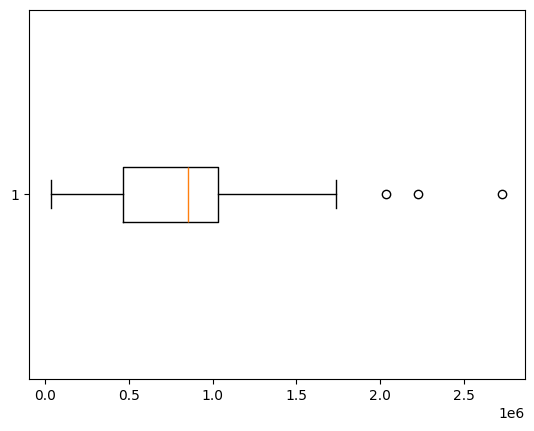

In [18]:
# code here
plt.boxplot(x = yearly_gas_sum, vert=False);

- Apakah data memiliki outlier?

> Ada, data yang memiliki nilai diatas 2 juta MCF dianggap outlier

- Bagaimana bentuk distribusi data?

> Data kita skewed right

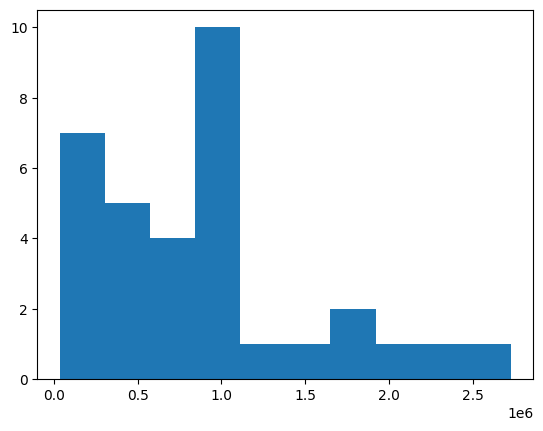

In [19]:
plt.hist(x = yearly_gas_sum);

## Variable Relationship

Karena pada data kita punya banyak kolom atau variabel, kita juga ingin tahu hubungan antar variabel dalam data kita.

Ukuran yang digunakan untuk melihat **hubungan linear** antara dua variabel numerik.

### Covariance

Covariance menunjukkan bagaimana variansi 2 data (variable yang berbeda) bergerak bersamaan

* Formula Covariance: $$Cov(X, Y) = \frac{1}{n-1}\sum\limits^n_{i=1}(X_i - \bar{X})(Y_i - \bar{Y})$$
* Fungsi di pandas: `df.cov()`

![](assets/covariance-positive-vs-negative.jpg)

- Nilai covariance positif mengindikasikan pergerakan nilai yang searah / berbanding lurus.
- Nilai covariance negatif mengindikasikan pergerakan nilai yang berbalik arah.

**Contoh:**

Hitunglah covariance pada data `newyork` menggunakan `.cov()`. Bagaimana hubungan antara `Active Oil Wells` dengan `Oil Produced, bbl`?

⚠️ Jika pada data terdapat nilai bukan numerik, tambahkan parameter `numeric_only=True`

In [20]:
# code here
newyork.cov(numeric_only=True)['Active Oil Wells']

Production Year           -128.37
Active Oil Wells          6947.39
Inactive Oil Wells         361.44
Active Gas Wells           -26.06
Inactive Gas Wells          -5.74
Injection Wells           4260.60
Disposal Wells               0.20
Oil Produced, bbl      1463550.24
Gas Produced, Mcf       -28142.57
Water produced, bbl   25307879.64
Taxable Gas, Mcf         23345.03
Name: Active Oil Wells, dtype: float64

> Insight : `Active Oil Wells` dengan `Oil Produced, bbl` memiliki hubungan **positif**

📝 **Note:** 

Seperti variance, covariance tidak memiliki batasan nilai untuk mengukur kekuatan hubungan antar dua variabel (-inf s.d inf), sehingga kita hanya bisa mengetahui apakah hubungannya positif atau negatif. Oleh karena itu, hadir **correlation**.

### Correlation

Correlation memampatkan nilai covariance dari -inf s.d inf menjadi **-1 s.d 1** sehingga bisa diukur kekuatan hubungan antar data (variable).

* Formula Correlation: 

$$Cor(X,Y) = \frac{Cov(X,Y)}{\sqrt{Var(X)Var(Y)}}$$

* Fungsi di Pandas: `df.corr()`

- Nilai korelasi mengindikasikan kekuatan hubungan antara dua variable numerik sebagai berikut:

![](assets/correlation-coef.jpg)

Bila korelasi dua variable numerik mendekati:
  - -1 artinya korelasi negatif kuat
  - 0 artinya tidak berkorelasi
  - 1 artinya korelasi positif kuat

**Contoh:**

Hitunglah correlation pada data `newyork` menggunakan `.corr()`. Seberapa kuat hubungan antara `Active Oil Wells` dengan `Oil Produced, bbl`?

In [21]:
# code here
newyork.corr(numeric_only=True)

,Production Year,Active Oil Wells,Inactive Oil Wells,Active Gas Wells,Inactive Gas Wells,Injection Wells,Disposal Wells,"Oil Produced, bbl","Gas Produced, Mcf","Water produced, bbl","Taxable Gas, Mcf"
Production Year,1.00,-0.19,-0.24,0.00,-0.11,-0.10,-0.06,-0.19,-0.05,-0.17,0.01
Active Oil Wells,-0.19,1.00,0.30,-0.04,-0.04,0.81,0.03,0.74,-0.00,0.45,0.01
Inactive Oil Wells,-0.24,0.30,1.00,-0.06,0.20,0.28,-0.01,0.25,-0.03,0.11,-0.02
Active Gas Wells,0.00,-0.04,-0.06,1.00,0.29,-0.03,0.18,-0.01,0.29,-0.03,0.22
Inactive Gas Wells,-0.11,-0.04,0.20,0.29,1.00,-0.02,-0.01,-0.02,0.17,-0.02,0.11
Injection Wells,-0.10,0.81,0.28,-0.03,-0.02,1.00,-0.00,0.67,-0.01,0.42,-0.00
Disposal Wells,-0.06,0.03,-0.01,0.18,-0.01,-0.00,1.00,0.02,-0.00,-0.00,0.00
"Oil Produced, bbl",-0.19,0.74,0.25,-0.01,-0.02,0.67,0.02,1.00,0.12,0.49,0.07
"Gas Produced, Mcf",-0.05,-0.00,-0.03,0.29,0.17,-0.01,-0.00,0.12,1.00,-0.02,0.57
"Water produced, bbl",-0.17,0.45,0.11,-0.03,-0.02,0.42,-0.00,0.49,-0.02,1.00,-0.01


> Insight : `Active Oil Wells` dengan `Oil Produced, bbl` memiliki hubungan **kuat** - **positif** 

**[Optional]** Visualisasi korelasi dengan heatmap:

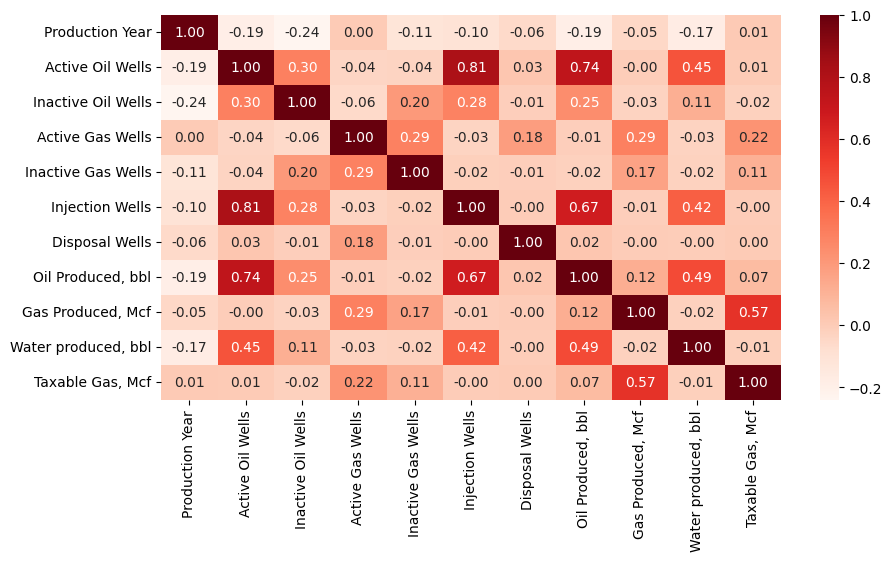

In [22]:
import seaborn as sns
plt.figure(figsize = (10,5))

fig = sns.heatmap(newyork.corr(numeric_only=True), # nilai korelasi
                  annot=True,   # anotasi angka di dalam kotak heatmap
                  fmt=".2f",    # format 3 angka dibelakang koma 
                  cmap='Reds'); # warna heatmap

### [Scatter Plot](https://www.data-to-viz.com/graph/scatter.html)

Sebuah scatterplot menampilkan visualisasi hubungan antara 2 variabel numerik. Untuk setiap titik data, nilai variabel pertama direpresentasikan pada sumbu X, yang kedua pada sumbu Y.

![correlation.png](assets/correlation.png)

🦉 Tips: Untuk memutuskan variabel mana yang akan ditempatkan pada sumbu x dan mana yang akan ditempatkan pada sumbu y, tampilkan variabel yang ingin Anda jelaskan atau prediksi sepanjang sumbu y.

**Bagaimana cara mengetahui bahwa scatter plot memiliki asosiasi?**

- tes visual: bandingkan dengan scatter plot lain dengan random data (tanpa pola). jika scatter plot asli terlihat ada pola, berarti ada asosiasi.

**Bagaimana kita menentukan asosiasi/hubungannya?**

- Arah: trend polanya naik, turun, atau keduanya?
- Lengkungan: apakah polanya linier atau melengkung?
- Variasi: Apakah titik-titiknya tersusun rapat di sepanjang pola?
- Outliers/Pencilan: Apakah Anda menemukan sesuatu yang tidak terduga?

> Scatter plot tidak mengukur kekuatan hubungan/asosiasi antara dua variabel numerik. Kita dapat menggunakan covariance atau korelasi untuk menentukan kekuatan asosiasi linier.

Untuk membuat visualisasi Scatter Plot, kita akan membutuhkan bantuan dari library baru yaitu `matplotlib.pyplot` dan menggunakan `plt.scatter()`.

Parameter `plt.scatter()`:
- `x` : Kolom numerik untuk sumbu x visualisasi
- `y` : Kolom numerik untuk sumbu y visualisasi

**Contoh: scatter plot antara data Active Oil Wells dan Oil Produced pada data `newyork`**

Buat sebuah Scatter Plot untuk memvisualisasikan hubungan antara `Active Oil Wells` dengan `Oil Produced, bbl`:

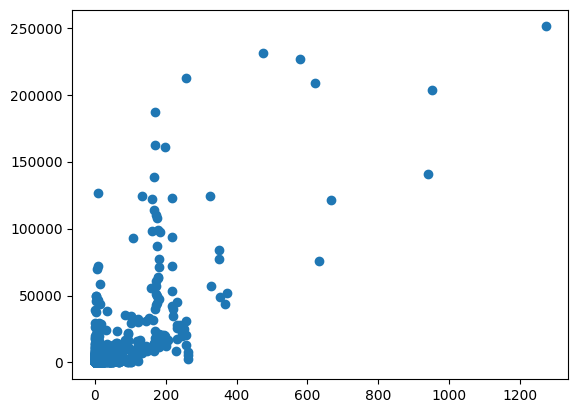

In [23]:
# code here
plt.scatter(x = newyork['Active Oil Wells'],
            y = newyork['Oil Produced, bbl'])

> Insight: `Active Oil Wells` dengan `Oil Produced, bbl` memiliki relationship **lemah** - **positif**

**Quick Summary Descriptive Statistics**

- **Central Tendency** = mean, modus, median
  + Untuk data numerik: mean & median
    - Ketika terdapat outlier: median
    - Ketika tidak terdapat outlier: mean
  + Untuk data kategorik : modus
  
- **Measure of Spread** = variance & sd/ standard deviasi
  + Variance tidak diinterpretasi secara sendirinya
  + Standard deviation memiliki satuan/skala normal, sehingga  bisa diinterpretasikan
  + Range dan IQR dapat divisualisasikan dengan boxplot
  
- **Variable Relationship**: covariance & correlation
  + covariance hanya bisa dilihat nilai positif dan negatifnya. 
    - Rangenya - inf s.d inf
  + correleation digunakan untuk mengukur kekuatan hubungan
    - Rangenya -1 s.d 1
    - semakin mendekati -1 $\rightarrow$ strong negative correlation
    - semakin mendekati 1 $\rightarrow$  strong positive correlation
    - semakin mendekati 0 $\rightarrow$ no correlation

-----

# Inferential Statistics

Inferential Statistics membantu kita **menarik kesimpulan tentang keseluruhan data (populasi) dengan menggunakan sebagian informasinya saja (sampel)**

![](assets/statistical_cycle.png)

Setiap data pasti memiliki distribusi. Salah satu jenis distribusi yang paling terkenal dan sering digunakan dalam statistik adalah **Distribusi Normal**. Distribusi ini berperan besar dalam inferential statistics.

## Normal Distribution

![](assets/normal-distribution.jpg)

Karakteristik:

- Kurva membentuk lonceng simetris, artinya puncaknya adalah titik pusat (mean = median)
- Luas area dibawah kurva = 1 (menyatakan probabilitas)
- Persebaran data:
  + 68% data berada di rentang +- 1 standar deviasi dari mean
  + 95% data berada di rentang +- 2 standar deviasi dari mean
  + 99.7% data berada di rentang +- 3 standar deviasi dari mean
- **Standar normal baku** adalah distribusi normal dimana mean = 0 dan standar deviasi = 1. 

Distribusi normal banyak digunakan pada inferensial statistik karena dicetuskannya **Central Limit Theorem**.

## Central Limit Theorem

Central Limit Theorem (CLT) menyatakan bahwa:

> The distribution of sample means will be normally distributed as long as the sample size is sufficiently large, regardless of the shape of the original population distribution.

Sehingga, jika kita mengambil sampel acak berulang kali dari suatu populasi (apa pun bentuk distribusinya) dan menghitung mean dari setiap sampel, maka distribusi mean sampel tersebut akan mendekati distribusi normal selama ukuran sampel cukup besar (biasanya n ≥ 30).

Kita akan coba membuktikan teorema tersebut dengan menggunakan data produksi minyak bumi dari sebelumnya:

Buat sebuah histogram dari `Oil Produced, bbl` dengan 30 bins!

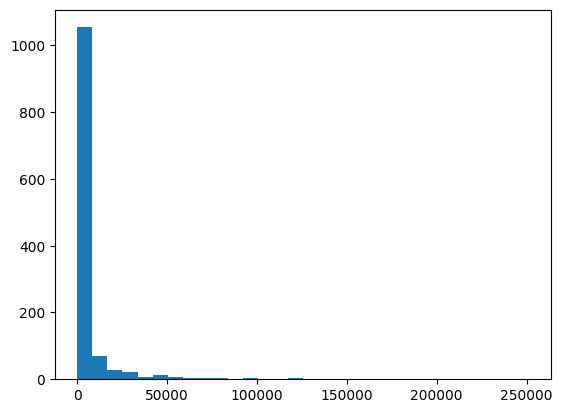

In [24]:
plt.hist(newyork['Oil Produced, bbl'], bins=30);

Perhatikan bahwa distribusi dari besar minyak bumi tidak berdistribusi normal. Sehingga, kita tidak bisa melakukan analisis distribusi normal secara langsung pada data tersebut. Namun, kita akan mencoba Central Limit Theorem untuk membuktikan apakah sampel mean dari data kita berdistribusi normal.

Gunakan for loop untuk mengisi list `sample_means` dengan rata-rata 100 sampel data yang diambil menggunakan method `.sample()` sebanyak 1000 kali:

In [25]:
# code here
sample_means = [] # blank list untuk menyimpan rata-rata sampel

# for loop
for i in range(10000):
    sample_means.append(newyork['Oil Produced, bbl'].sample(100, random_state=i).mean())

In [26]:
sample_means

[9828.62,
 5768.87,
 5866.61,
 10680.9,
 8191.61,
 5838.29,
 7644.51,
 8903.81,
 6067.01,
 3768.55,
 7461.86,
 11095.46,
 7924.5,
 8102.32,
 4517.05,
 5351.55,
 7092.75,
 6208.97,
 8184.51,
 7132.58,
 9962.25,
 9253.71,
 4490.63,
 5528.44,
 6688.81,
 4713.05,
 10789.09,
 8980.81,
 10584.66,
 10284.66,
 6888.08,
 8084.69,
 8923.66,
 9955.7,
 6058.41,
 7831.37,
 7539.86,
 6029.27,
 7917.2,
 5720.85,
 5863.03,
 6632.48,
 9055.47,
 14409.89,
 9537.1,
 4844.74,
 4913.24,
 3427.58,
 6469.04,
 7156.19,
 7297.02,
 10904.67,
 11641.32,
 6140.34,
 8864.37,
 11122.03,
 5369.86,
 4413.99,
 6340.96,
 8771.76,
 5609.92,
 5514.37,
 8569.81,
 6929.04,
 10994.85,
 8356.09,
 5689.13,
 5746.42,
 13677.13,
 5127.17,
 9610.0,
 11889.95,
 4732.3,
 6844.82,
 5197.5,
 6274.1,
 7628.98,
 4176.77,
 5905.65,
 6554.15,
 7480.8,
 6233.11,
 2969.35,
 7817.86,
 6091.86,
 8672.56,
 6477.11,
 6183.62,
 8794.54,
 5351.18,
 10494.64,
 8315.14,
 10781.52,
 7970.64,
 10773.01,
 5741.45,
 9593.9,
 7209.76,
 6561.87,
 9162.

Kemudian, buat histogram untuk melihat distribusi dari `sample_means`!

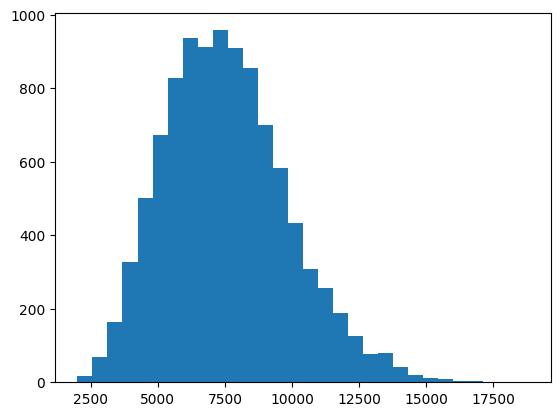

In [27]:
# code here
plt.hist(sample_means, bins=30);

Jalankan code berikut untuk membandingkan distribusi data diatas (histogram) dengan distribusi normal (garis merah)!

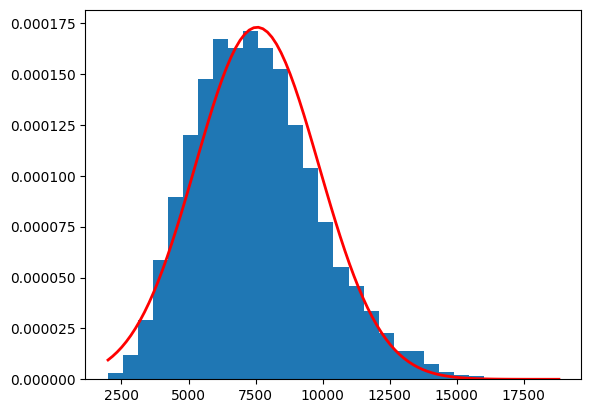

In [28]:
from scipy.stats import norm

x = np.linspace(start=np.min(sample_means), stop=np.max(sample_means), num=100)   # buat 100 titik antara min-max
p = norm.pdf(x, loc=np.mean(sample_means), scale=np.std(sample_means))  # hitung nilai PDF normal di titik x

plt.hist(sample_means, bins=30, density=True);
plt.plot(x, p, 'r', linewidth=2, label="Distribusi Normal");

🔎 **Discussion**: Apakah `sample_means` mendekati distribusi normal?

Karakteristik distribusi normal inilah yang dimanfaatkan untuk penghitungan inferensial statistik:

- **Probability Density Function**
- **Confidence Interval**
- **Hypothesis Testing**

## Probability Mass Function

* Menghitung peluang untuk data diskrit, contoh:
  + peluang hujan/tidak hujan
  + peluang produk yang terjual
  + peluang nasabah good credit/bad credit
  
* Formula: jumlah kejadian terjadi dibagi dengan jumlah kejadian total

**Contoh:** Berapakah peluang bahwa laporan produksi minyak dan gas bumi dilakukan oleh operator **Pennzoil Products Co.**?

In [29]:
# code here
newyork[newyork['Operator']=='Pennzoil Products Co.']['Operator'].count()/newyork['Operator'].count()*100

4.923325262308313

🔎 **Insight**: Peluang laporan produksi minyak dan gas bumi dilakukan oleh operator **Pennzoil Products Co.** adalah ... %

Namun, bagaimana kalau kita ingin menghitung peluang untuk data numerik?

**Contoh:** Berapakah peluang bahwa sebuah oil field akan memiliki produksi minyak bumi lebih besar dari **10,000 barrel**?

In [30]:
# code here
newyork[newyork['Oil Produced, bbl']>10000]['Operator'].count()/newyork['Oil Produced, bbl'].count()*100

13.801452784503631

🔎 **Insight**: Peluang sebuah oil field akan memiliki produksi minyak bumi lebih besar dari **10,000 barrel** adalah ... %

## Probability Density Function

Probability Density Function menghitung probability data **kontinu dalam suatu interval** dengan memanfaatkan distribusi data.

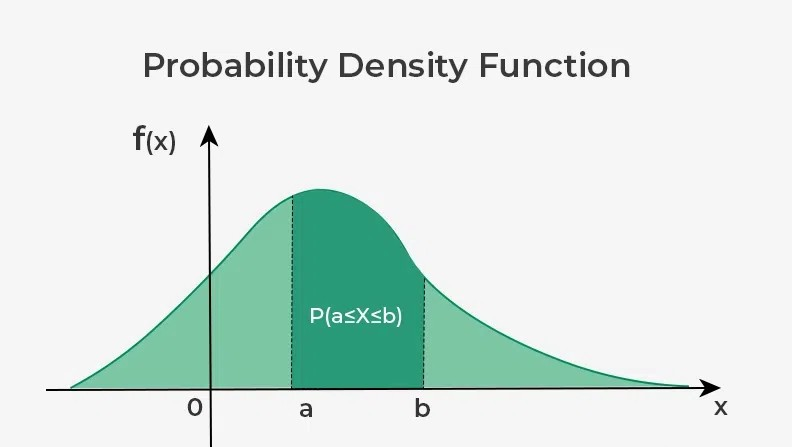

Di mana umumnya, untuk menghitung probability data di antara interval a dan b ($P(a \leq X \leq b)$) dapat dihitung menggunakan luas area dibawah kurva distribusi:

$P(a \leq X \leq b) = \int_{a}^{b} f(x)\,dx$


Namun, untuk distribusi normal, kita sudah mengetahui berapa besar persentase populasi data berdasarkan standar deviasinya. Menggunakan acuan tersebut, kita dapat menghitung luas area dibawah kurva dengan menggunakan **Z-Score**.

> Z-score merupakan sebuah nilai yang merepresentasikan **berapa standard deviasi data tersebut menyimpang dari rata-ratanya**

**Formula Z-score**:

$Z = \frac{x-\mu}{\sigma}$

Keterangan:

- $Z$ = Z-score
- $x$ = titik data
- $\mu$ = mean
- $\sigma$ = standar deviasi

Untuk melakukan perhitungan Z-Score menggunakan distribusi normal, kita akan menggunakan fungsi-fungsi yang terdapat pada module `norm` yang merupakan bagian dari library `scipy`

In [31]:
from scipy.stats import norm # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

Tahapan perhitungan probability density function menggunakan Z-Score:

  1. Hitung Mean dan Standar Deviasi data
  2. Hitung Z-score (ubah nilai data asli ke standar normal baku = Z-score standardization)
  3. Hitung peluang (area di bawah kurva) berdasarkan Z-score menggunakan CDF

**Contoh**: Tinggi badan pria dewasa di Indonesia berdistribusi normal dengan rata-rata 165 cm dan standar deviasi 10 cm. Berapa peluang pria dewasa di Indonesia memiliki tinggi badan > 180 cm?

1️⃣ Hitung Mean dan Standar Deviasi data!

In [32]:
# code here
mean = 165
std = 10
titik_data = 180

2️⃣ Hitung Z-Score ($Z = \frac{x-\mu}{\sigma}$) dari titik data yang ingin dicari peluangnya!

In [33]:
# code here
Z_score = (titik_data - mean) / std
Z_score

1.5

> **Interpretasi**: Tinggi badan pria dewasa Indonesia 180cm menyimpang ... std dari rata-rata

3️⃣ Hitung peluang berdasarkan Z-Score yang sudah diperoleh menggunakan *Cumulative Distribution Function (CDF)*:

*Cumulative Distribution Function (CDF)* adalah fungsi yang digunakan untuk menghitung area/luas di bawah kurva dari titik z sampai ujung kiri kurva

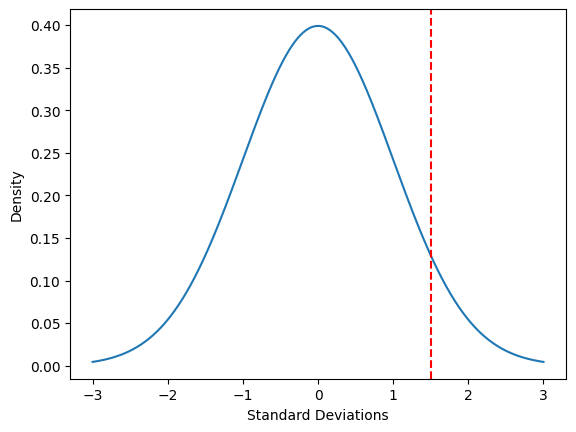

In [34]:
# membuat dummy normal distribution
x = np.linspace(-3, 3, 1000)
y = norm.pdf(x)

# Ilustasi titik Z-Score pada distribusi normal
plt.ylabel('Density')
plt.xlabel('Standard Deviations')
plt.plot(x, y)
plt.axvline(Z_score, color = "red", linestyle = "--")

Untuk menghitung peluang dari Z-Score, kita dapat menggunakan fungsi `cdf()` dari module `norm`

In [35]:
# code here
cdf = stats.norm.cdf(Z_score)
cdf*100

93.3192798731142

> **Interpretasi**: Peluang tinggi badan pria dewasa **DIBAWAH** 180cm adalah ... %

Maka, peluang pria dewasa di Indonesia memiliki tinggi badan **DIATAS** 180 cm adalah ...

In [36]:
# code here
cdf = 1-stats.norm.cdf(Z_score)
cdf*100

6.6807201268858085

> **Interpretasi**: Peluang tinggi badan pria dewasa **DIATAS** 180cm adalah ... %

📝 **Alternatif**: Pada fungsi `norm.cdf()`, terdapat parameter yang dapat mengatur titik tengah (`loc`) dan skala (`scale`) dari distribusi normal:

- `loc` : Berfungsi untuk mengatur titik tengah dari distribusi, merepresentasikan nilai mean dari distribusi normal (default = 0)
- `scale` : Berfungsi untuk mengatur skala distribusi, merepresentasikan nilai standar deviasi dari distribusi normal (default = 1)

Sehingga, dengan menggunakan parameter-parameter tersebut, kita tidak perlu menghitung Z-Score secara manual.

**Contoh**: Tinggi badan wanita dewasa di Indonesia berdistribusi normal dengan rata-rata 155 cm dan standar deviasi 10 cm. Berapa peluang wanita dewasa di Indonesia memiliki tinggi badan kurang dari 150 cm?

In [37]:
# code here
mean = 155
std = 10
titik_data = 150
# cdf
Z_score = (titik_data - mean) / std
cdf = stats.norm.cdf(Z_score)
cdf*100

30.853753872598688

> **Interpretasi**: Peluang tinggi badan wanita dewasa dibawah 150cm adalah ... %

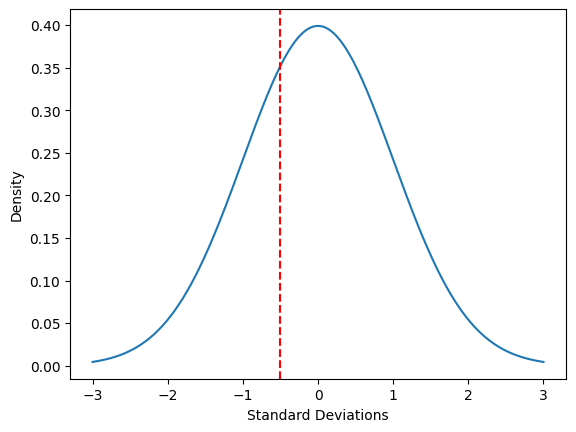

In [38]:
x = np.linspace(-3, 3, 1000)
y = norm.pdf(x)

# Ilustasi titik Z-Score pada distribusi normal
plt.ylabel('Density')
plt.xlabel('Standard Deviations')
plt.plot(x, y);
plt.axvline((150 - mean)/std, color = "red", linestyle = "--");

### 🏄 Dive deeper: Probability Density Function

Menggunakan data `sample_means` dari data produksi minyak dan gas bumi Ney York, kita ingin menganalisis potensi produksi minyak bumi pada setiap formasi sumur minyak bumi. Berapakah peluang rata-rata produksi minyak bumi (`Oil Produced, bbl`) berada pada rentang  **7.500 - 10.000 bbl**?

In [39]:
# code here
mean = np.mean(sample_means)
std = np.std(sample_means)
titik_data_1 = 7500
Z_score = (titik_data_1 - mean) / std
cdf = stats.norm.cdf(Z_score)
cdf_a = cdf*100
cdf_a = float(cdf_a)
cdf_a

49.00817854260134

In [40]:
# code here
mean = np.mean(sample_means)
std = np.std(sample_means)
titik_data_2 = 10000
Z_score = (titik_data_2 - mean) / std
cdf = stats.norm.cdf(Z_score)
cdf_b = cdf*100
cdf_b = float(cdf_b)
cdf_b

85.52518653822486

In [41]:
abs(cdf_a - cdf_b)

36.517007995623516

## Confidence Interval

Confidence interval berguna untuk memperkirakan nilai mean populasi dengan sebuah interval berdasarkan informasi dari sample data. Mengetahui interval tersebut akan meminimalisir error dibandingkan hanya dengan menebak satu nilai.

-  Formula: 

    $CI = \bar{x} \pm Z*SE$

- Keterangan: 
  + $\bar{x}$ = rata-rata sampel
  + $Z$ = Z-score untuk confidence level (tingkat kepercayaan)
  + SE = standard error
  
**Standard Error (SE)** merupakan standar deviasi dari populasi. Semakin kecil nilai standard error, maka rentang confidence interval semakin kecil dan sampel semakin representatif (baik).
-  Formula: 

    $SE = \frac{\sigma}{\sqrt n}$

- Keterangan: 
  + $\sigma$ = standar deviasi
  + $n$ = jumlah sampel

**Confidence Level / Tingkat Kepercayaan**

Confidence Level atau Tingkat Kepercayaan adalah sebuah nilai yang menggambarkan seberapa yakin kita bahwa Confidence Interval akan akurat. Umumnya, confidence level adalah sebesar 95%, berarti jika kita mengambil banyak sampel dan menghitung CI untuk masing-masing sampel, sekitar 95% dari interval tersebut akan mengandung nilai sebenarnya dari populasi. Sisa 5% yang berada diluar di luar CI akan dianggap sebagai outlier.

![confidence_interval.jpg](assets/confidence_interval.jpg)

📝 **Tahapan**:

  1. Hitung mean dan standar deviasi sample
  2. Hitung Z-Score untuk tingkat kepercayaan yang ditentukan
  3. Hitung Standard Error
  4. Hitung confidence interval

**Contoh**

Data `newyork` berisi data yang sudah disampel dari tahun 1967 hingga 1999. Kita ingin mengetahui berapa rata-rata produksi minyak bumi di New York secara keseluruhan, tidak terbatas dari tahun datanya diambil saja. 

Cari confidence interval dengan tingkat kepercayaan 95% dari produksi minyak bumi tahunan keseluruhan di New York!

In [53]:
# code here
yearly_oil_average = newyork['Oil Produced, bbl'].groupby(newyork['Production Year']).mean().reset_index()
yearly_oil_average

,Production Year,"Oil Produced, bbl"
0,1967,4204.62
1,1968,31572.67
2,1969,16763.53
3,1970,11067.04
4,1971,11828.67
5,1972,6916.25
6,1973,13703.62
7,1974,8325.91
8,1975,8095.25
9,1976,16652.35


1️⃣ Hitung mean dan standar deviasi sample:

In [54]:
# code here
mean = yearly_oil_average['Oil Produced, bbl'].mean()
std = yearly_oil_average['Oil Produced, bbl'].std()

print('mean: ', mean)
print('std: ', std)

mean:  9918.560737411924
std:  8496.448713499143


2️⃣ Hitung Z-Score untuk tingkat kepercayaan yang ditentukan

Untuk menghitung Z-Score dari probability, kita dapat menggunakan **Probability Point Function** (PPF). PPF merupakan nilai inverse dari CDF, yang dapat kita gunakan untuk menghitung nilai Z-Score dari nilai probability (kebalikan dari CDF yang digunakan untuk menghitung probability dari nilai Z-Score)

PPF  dapat dihitung dengan menggunakan fungsi `ppf()` dari module `norm`

In [56]:
# Z-score untuk tingkat kepercayaan 0.025 atau 2.5%
Z = stats.norm.ppf(0.025)
Z

-1.9599639845400545

**📝 Notes:**

- `norm.cdf()` untuk mencari peluang (x) dari sebuah titik/nilai Z di distribusi normal baku
- `norm.ppf()` untuk mencari titik/nilai Z dari sebuah peluang (x) di distribusi normal baku

3️⃣ Hitung Standard Error $(SE = \frac{\sigma}{\sqrt n})$

Untuk menghitung akar kuadrat, kita dapat menggunakan fungsi `sqrt()` dari module `math`.

In [57]:
# import function square root
from math import sqrt

In [58]:
yearly_oil_average

,Production Year,"Oil Produced, bbl"
0,1967,4204.62
1,1968,31572.67
2,1969,16763.53
3,1970,11067.04
4,1971,11828.67
5,1972,6916.25
6,1973,13703.62
7,1974,8325.91
8,1975,8095.25
9,1976,16652.35


In [59]:
# Jumlah Sampel
n = 32

# std  dibagi akar n
SE = std / (n ** 0.5)

4️⃣ Hitung confidence interval ($CI = \bar{x} \pm Z*SE$)

In [60]:
lower = mean + (Z * SE)
upper = mean - (Z * SE)

print(lower)
print(upper)

6974.745546054583
12862.375928769266


> Kesimpulan: Dengan tingkat keyakinan 95%, maka rata-rata produksi minyak `Oil Produced, bbl` untuk setiap tahunnya pada data NYC berada pada .... hingga ... barrel

## Hypothesis Testing

Uji hipotesis bertujuan statistik untuk mengambil keputusan tentang suatu klaim (hipotesis) mengenai populasi berdasarkan data sampel. Uji hipotesis sering disebut juga sebagai **uji signifikansi** yang digunakan untuk menguji apakah suatu treatment memberikan perubahan/pengaruh signifikan terhadap suatu kondisi.

Uji hipotesis dilakukan dengan mendefinisikan 2 hipotesis:

  + $H_0$ / null hypothesis: 
    * dugaan awal, tidak ada perbedaan
  + $H_1$ / alternative hypothesis: 
    * dugaan tandingan, ada perbedaan yang signifikan

**Jenis-Jenis Hypothesis Testing**

1. Hipotesis dua arah (!=)

- $H_0$ : Rata-rata saldo rekening tidak berbeda secara signifikan antara nasabah yang menggunakan layanan internet banking dan yang tidak menggunakan layanan tersebut. (=)
- $H_1$ : Rata-rata saldo rekening **berbeda secara signifikan** antara nasabah yang menggunakan layanan internet banking dan yang tidak menggunakan layanan tersebut. (!=)

2. Hipotesis satu arah (<)

- $H_0$ : Penambahan teller tidak memberikan perbedaan durasi pembayaran (>=)
- $H_1$ : Penambahan teller **menurunkan** durasi pembayaran (<)

3. Hipotesis satu arah (>)

* $H_0$: Penerapan diskon tidak memberikan perbedaan jumlah pembelian produk (<=)
* $H_1$: Penerapan diskon **meningkatkan** jumlah pembelian produk (>)

**Pengambilan Keputusan**

Untuk mengambil keputusan dari hypothesis testing, kita akan mengacu pada nilai **P-Value**. P-Value adalah hasil perhitungan statistik yang menunjukkan peluang data sampel terjadi dengan kondisi $H_0$. Sehingga, jika peluangnya sangat kecil untuk $H_0$ terjadi (P < $\alpha$), kita dapat tolak $H_0$.

- Jika **p-value** < $\alpha$, maka tolak $H_0$ -> terima $H_1$
- Jika **p-value** > $\alpha$, maka gagal tolak $H_0$ -> terima $H_0$

dimana $\alpha$:

  + tingkat signifikansi yaitu tingkat error yang masih bisa ditoleransi
  + $1-\alpha$ = tingkat kepercayaan
  + umumnya 0.05 (untuk tingkat kepercayaan 95%)

### Z-Test

Z-Test Hypothesis Testing adalah metode uji hipotesis yang memanfaatkan distribusi normal untuk menentukan signifikansi rata-rata sebuah sample.

Daerah/area yang kita ingin uji dilihat dari tanda ketidaksamaan di hipotesis alternatif

![](assets/p-value.PNG)

**Contoh**

Perusahaan telah mengupgrade mesin pengeboran untuk meningkatkan efisiensi produksi pada tahun 2000. Setelah mesin tersebut diterapkan, telah diperoleh sebanyak **50** sample data produksi minyak bumi pada tahun 2000 yang disimpan pada sebuah file csv `data_input/New_York_Oil_and_Gas_2000.csv`.

Sebagai seorang Analyst, Anda diminta untuk menguji apakah dengan melakukan upgrade mesin pengeboran baru secara rata-rata tersebut meningkatkan laju produksi secara signifikan atau tidak. Gunakan tingkat kepercayaan sebesar **95%** ($\alpha$ = 0.05) untuk menentukan signifikansi hasil.

Jawaban:

1️⃣ **Tentukan hipotesis**

$H_0$: 

$H_1$: 

2️⃣ **Dapatkan data untuk dibandingkan**

Data yang akan digunakan untuk uji hipotesis adalah data produksi minyak dan gas bumi New York pada tahun 2000

In [61]:
# data produksi mesin baru tahun 2000
newyork_2000 = pd.read_csv('data_input/New_York_Oil_and_Gas_2000.csv')
newyork_2000.head()

,Production Year,Production Date Entered,Operator,County,Town,Field,Producing Formation,Active Oil Wells,Inactive Oil Wells,Active Gas Wells,Inactive Gas Wells,Injection Wells,Disposal Wells,Self-use Well,"Oil Produced, bbl","Gas Produced, Mcf","Water produced, bbl","Taxable Gas, Mcf",Purchaser Codes,Location
0,2000,2001-08-24,Pennzoil Products Co.,Cattaraugus,CARROLLTON,CHIPMUNK,CHIPMUNK,951,18,1,0,798,0,NO,304858.50,54557,3858936,5062,"OA,OX","CARROLLTON, NY\n(42.023289, -78.628438)"
1,2000,2001-04-11,Rogor Petroleum Corp.,Cattaraugus,OLEAN,BRADFORD,BRADFORD,20,0,0,0,0,0,NO,2749.50,2700,1200,0,NaN,"OLEAN, NY\n(42.077495, -78.429849)"
2,2000,2001-06-22,Seis-Ex Geophysical Ltd,Chautauqua,KIANTONE,LAKESHORE,MEDINA,3,5,1,1,0,0,YES,619.50,11098,3435,0,NaN,"KIANTONE, NY\n(42.021944, -79.198276)"
3,2000,2001-08-22,Messer Oil Corp.,Allegany,BOLIVAR,RICHBURG,RICHBURG,28,30,1,0,0,0,NO,2224.50,1800,0,0,NaN,"BOLIVAR, NY\n(42.066701, -78.167667)"
4,2000,2001-04-19,Quaker State Corp.,Cattaraugus,OLEAN,FIVE MILE,BRADFORD,9,0,0,0,0,0,YES,619.50,400,40,0,NaN,"OLEAN, NY\n(42.077495, -78.429849)"


3️⃣ **Hitung P-Value dengan menggunakan [`ztest()`](https://www.statsmodels.org/devel/generated/statsmodels.stats.weightstats.ztest.html)**

Fungsi `ztest()` dari library `statsmodels` dapat digunakan untuk menghitung z-score dan p-value.

```python
from statsmodels.stats.weightstats import ztest

zscore, pval = ztest(x1 = hypothesis_sample,
                     value = sample_mean_value,
                     alternative = 'metode')
```
parameter :
- `x1` : sample data yang ingin diuji (data berupa **array**)
- `value` : value sample mean data historis (data berupa **numeric**)
- `alternative` : tergantung hypothesis alternative ($H_1$)
   - jika $H_1$ adalah mean `x1` tidak sama (!=) dibanding `value`, isi dengan `two-sided`
   - jika $H_1$ adalah mean `x1` lebih besar (>) dibanding `value`, isi dengan `larger`
   - Jika $H_1$ adalah mean `x1` lebih besar (<) dibanding `value`, isi dengan `smaller`

In [69]:
# code here
from statsmodels.stats.weightstats import ztest

zscore, pval = ztest(newyork_2000['Oil Produced, bbl'], value=mean, alternative='two-sided')

print('Z-Score :', zscore)
print('P-Value :', pval)

Z-Score : 0.9993019032447922
P-Value : 0.3176484637399789


4️⃣ **Bandingkan P-value dengan alpha**

Pengambilan kesimpulan:

* Jika **p-value** < $\alpha$, maka tolak $H_0$ 
* Jika **p-value** > $\alpha$, maka gagal tolak $H_0$

**p-value** lebih **besar/kecil** dari $\alpha$, maka **tolak/gagal tolak** $H_0$

5️⃣ **Kesimpulan**

> ...


### Two Sample Z-Test

Two sample Z-test membandingkan dua sampel independen, berbeda dengan Z-Test sebelumnya (one sample Z-test) yang membandingkan suatu sampel terhadap nilai rata-rata. Perbedaan utama nya terletak pada perhitungannya, dimana Two sample Z-test akan mempertimbangkan variance dari kedua sample (one sample Z-test mengasumsikan standard deviation sama).

1️⃣ **Hitung P-Value dengan menggunakan [`ztest()`](https://www.statsmodels.org/devel/generated/statsmodels.stats.weightstats.ztest.html)**

Fungsi `ztest()` dari library `statsmodels` dapat digunakan untuk menghitung z-score dan p-value.

```python
from statsmodels.stats.weightstats import ztest

zscore, pval = ztest(x1 = hypothesis_sample,
                     x2 = historical_sample,
                     alternative = 'metode')
```
parameter :
- `x1` : sample data yang ingin diuji (data berupa **array**)
- `x2` : sample data historis (data berupa **array**)
- `alternative` : tergantung hypothesis alternative ($H_1$)
   - jika $H_1$ adalah mean `x1` tidak sama (!=) dibanding mean `x2`, isi dengan `two-sided`
   - jika $H_1$ adalah mean `x1` lebih besar (>) dibanding mean `x2`, isi dengan `larger`
   - Jika $H_1$ adalah mean `x1` lebih besar (<) dibanding mean `x2`, isi dengan `smaller`

In [65]:
# code here
from statsmodels.stats.weightstats import ztest

zscore, pval = ztest(x1= newyork_2000['Oil Produced, bbl'], value=newyork['Oil Produced, bbl'].mean(), alternative='larger')

print('Z-Score :', zscore)
print('P-Value :', pval)

Z-Score : 1.2711330439221822
P-Value : 0.10184066076722287


2️⃣ **Bandingkan P-value dengan alpha**

Pengambilan kesimpulan:

* Jika **p-value** < $\alpha$, maka tolak $H_0$ 
* Jika **p-value** > $\alpha$, maka gagal tolak $H_0$

**p-value** lebih **besar/kecil** dari $\alpha$, maka **tolak/gagal tolak** $H_0$

3️⃣ **Kesimpulan**

> ...


### T-test

Uji hipotesis menggunakan T-test jika:

* standar deviasi populasi tidak diketahui atau
* jumlah sampel sedikit (n <= 30)

Bentuk t-distribution mirip dengan normal distribution, hanya saja lebih landai ketika jumlah sampel sedikit:

<img src="assets/t-distribution.jpg" width="800">

**Contoh**

Untuk lebih memahami tentang uji-t, pertimbangkan skenario berikut:

Sebuah perusahaan minyak sedang mengevaluasi efektivitas dua teknik drilling/pengeboran yang berbeda: Teknik A dan Teknik B.

In [66]:
# barrel per day
technique_a = pd.Series([2000, 2100, 2050, 1980, 2150, 2050, 2025, 2075, 2100, 1950])
technique_b = pd.Series([2025, 2175, 1980, 2150, 2125, 2180, 2150, 2100, 1990, 1975])

print('Mean Technique A :', technique_a.mean())
print('Mean Technique B :', technique_b.mean())

Mean Technique A : 2048.0
Mean Technique B : 2085.0


Perusahaan ingin menguji dengan tingkat kepercayaan 95%, **apakah terdapat perbedaan yang signifikan dalam rata-rata laju produksi antara sumur yang dibor menggunakan Teknik A dan sumur yang dibor menggunakan Teknik B?**

Jawab:

1️⃣ **Tentukan Hipotesis**.

- $H_0$: Rata-rata tingkat produksi antara sumur yang dibor dengan menggunakan Teknik A dan Teknik B sama.
- $H_1$: Rata-rata tingkat produksi antara sumur yang dibor dengan menggunakan Teknik A dan Teknik B berbeda dengan signifikan.

2️⃣ **Hitung P-Value dengan menggunakan [`ttest_ind()`](https://www.statsmodels.org/stable/generated/statsmodels.stats.weightstats.ttest_ind.html)**

Fungsi `ttest_ind()` dari library `statsmodels` dapat digunakan untuk menghitung T-score dan P-value.

```python
from statsmodels.stats.weightstats import ttest_ind

tstats, pval, dof = ttest_ind(x1 = sample_data_1,
                              x2 = sample_data_2,
                              alternative = 'two-sided')
```
parameter :
- `x1` : sample data yang ingin diuji (data berupa **array**)
- `x2` : sample data yang ingin diuji (data berupa **array**)
- `alternative` : tergantung hypothesis alternative ($H_1$)
   - jika $H_1$ adalah mean `x1` tidak sama (!=) dibanding `x2`, isi dengan `two-sided`
   - jika $H_1$ adalah mean `x1` lebih besar (>) dibanding `x2`, isi dengan `larger`
   - Jika $H_1$ adalah mean `x1` lebih besar (<) dibanding `x2`, isi dengan `smaller`

In [67]:
# code here
from statsmodels.stats.weightstats import ttest_ind

tstats, pval, dof = ttest_ind(technique_a, technique_b, alternative='two-sided', usevar='unequal')

print('T-Stats :', tstats)
print('P-Value :', pval)

T-Stats : -1.1284311051151146
P-Value : 0.27531218089821596


3️⃣ **Bandingkan P-value dengan alpha**

Dalam membuat keputusan uji statistik, kita dapat membandingan p-value dengan alpha:

* Jika **p-value** < $\alpha$, maka tolak $H_0$ 
* Jika **p-value** > $\alpha$, maka gagal tolak $H_0$

**p-value** lebih **besar/kecil** dari $\alpha$, maka **tolak/gagal tolak** $H_0$

4️⃣ **Kesimpulan**

> Technique A dan B tidak memiliki perbedaan signifikan

### ANOVA (Analysis of Variance)

**Analysis of Variance (ANOVA)** adalah metode statistik yang digunakan untuk menguji apakah terdapat perbedaan yang signifikan antara mean dari tiga atau lebih kelompok independen. Jika **t-test** terbatas hanya untuk membandingkan dua kelompok, maka **ANOVA** memperluas konsep tersebut, menjadikannya sangat berguna dalam aplikasi industri di mana beberapa proses, perlakuan, atau metode diuji secara bersamaan.

Hipotesis yang dapat dirumuskan dengan ANOVA adalah sebagai berikut:

   * $H_0$: Semua mean kelompok adalah sama.  
   * $H_1$: Setidaknya ada satu mean kelompok yang berbeda secara signifikan.


Uji ini bekerja dengan menganalisis rasio antara **variance antar kelompok (between-group variance)** dengan **variance dalam kelompok (within-group variance)**.

<img src="assets/anova_between_only.png" width="500"> <img src="assets/anova_within_only.png" width="500">


Untuk membuat keputusan, ANOVA akan menggunakan perhitungan F-statistic dengan formula:

$F = \frac{\text{Variance Between Groups}}{\text{Variance Within Groups}}$

Jika variasi antar kelompok jauh lebih besar dibanding variasi acak di dalam kelompok, F-statistic akan tinggi dan nilai P-value akan turun, sehingga $H_0$ akan dapat ditolak.

Sehingga, seperti sebelumnya, kita dapat mengambil kesimpulan:

   * Jika **p-value < $\alpha$**, maka tolak $H_0$ (setidaknya satu mean kelompok berbeda).
   * Jika **p-value > $\alpha$**, maka gagal menolak $H_0$ (tidak ada perbedaan signifikan yang terdeteksi).

**Contoh**

Perusahaan ingin menentukan operator manakah yang memiliki produksi paling baik dibandingkan dengan operator-operator lainnya. Anda ingin fokus membandingkan 3 operator dengan jumlah laporan terbanyak, yaitu operator `Pennzoil Products Co.`, `Richardson Petroleum Corp.`, dan `Yahn & Yahn, Inc.`. Gunakan **ANOVA** hypothesis testing untuk menentukan apakah terdapat perbedaan yang signifikan antara ketiga operator tersebut!

1️⃣ **Tentukan Hipotesis**.

* $H_0$: 
* $H_1$: 

2️⃣ **Dapatkan data untuk dibandingkan**

Data yang akan digunakan untuk uji hipotesis ANOVA adalah data produksi minyak bumi oleh operator `Pennzoil Products Co.`, `Richardson Petroleum Corp.`, dan `Yahn & Yahn, Inc.`

In [86]:
newyork['Operator'].unique()

array(['Resource Exploration, Inc.', 'F & T Oil', 'Pennzoil Products Co.',
       'Universal Resources Holdings, Incorporated',
       'Ekas, David & Archer', 'J G & A Co-Venture',
       'Winger, Philip G. & Diane E.', 'National Fuel Gas Supply Corp.',
       'Potter Oil Co.', 'Arrowhead Gas Producers, Inc.',
       'Beaver, Albert H', 'Roberts, Carl H',
       'American Penn Energy,  Inc.', 'Keystone Energy Oil & Gas, Inc',
       'Richardson Petroleum Corp.', 'Miller Oil Co.',
       'Miller Drilling Co.', 'Columbia Gas Transmission Corp.',
       'Envirogas, Inc.', 'Berea Oil & Gas Corp.',
       'Frank H. Stephan Oil Group', 'Huntington, Barbara A.',
       'Rogor Petroleum Corp.', 'Dudar, John', 'Quaker State Corp.',
       'Don-Bess Energy Develop. Co.', 'J and  R Oil Company',
       'Tellinghuisen, George', 'Estate of  Richard G Smith',
       'Chautauqua Energy, Inc.', 'Cooper, Brian C',
       'Libra Petroleum Company', 'Lenacre Oil Co.',
       'C & R Oil & Gas Corp.', 'Yah

In [87]:
# code here
pennzoil = np.array(newyork[newyork['Operator']=='Pennzoil Products Co.']['Oil Produced, bbl'])
richardson = np.array(newyork[newyork['Operator']=='Richardson Petroleum Corp.']['Oil Produced, bbl'])
yahn = np.array(newyork[newyork['Operator']=='Yahn & Yahn, Inc.']['Oil Produced, bbl'])   

In [88]:
len(pennzoil), len(richardson), len(yahn)

(61, 49, 47)

3️⃣ **Hitung P-Value dengan menggunakan [`f_oneway()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html)**

Fungsi `f_oneway()` dari library `statsmodels` dapat digunakan untuk menghitung F-statistics dan P-value.

```python
from scipy.stats import f_oneway

f_stat, pval = f_oneway(sample_data_1, sample_data_2, sample_data_3)
```

In [89]:
# code here
from scipy.stats import f_oneway

f_stat, pval = f_oneway(pennzoil, richardson, yahn)

print('F-Stats :', f_stat)
print('P-Value :', pval)

F-Stats : 21.045700691067875
P-Value : 8.313561907427994e-09


4️⃣ **Bandingkan P-value dengan alpha**

Pengambilan kesimpulan:

* Jika **p-value** < $\alpha$, maka tolak $H_0$ 
* Jika **p-value** > $\alpha$, maka gagal tolak $H_0$

**p-value** lebih **besar/kecil** dari $\alpha$, maka **tolak/gagal tolak** $H_0$

5️⃣ **Kesimpulan**

> ...


### Post Hoc Test

**ANOVA** memberi tahu kita bahwa ada perbedaan yang signifikan, tetapi tidak menjelaskan *kelompok mana* yang berbeda. Untuk mengetahui secara spesifik di mana perbedaan tersebut terjadi, kita melakukan **Post Hoc Test**. Salah satu Post Hoc Test yang sering digunakan adalah **Tukey’s HSD (Honestly Significant Difference)** yang berfungsi untuk membandingkan semua pasangan kelompok untuk melihat mana yang berbeda secara signifikan.


**Contoh**

Melanjutkan dari **ANOVA** sebelumnya, misalkan kita ingin mengetahui **operator manakah** yang memiliki performa lebih baik:


1️⃣ **Dapatkan data untuk dibandingkan**

Data yang akan digunakan untuk uji hipotesis ANOVA adalah data produksi minyak bumi oleh operator `Pennzoil Products Co.`, `Richardson Petroleum Corp.`, dan `Yahn & Yahn, Inc.`, Namun berbeda dengan ANOVA, untuk post hoc test membutuhkan 2 kolom, yaitu kolom value dan kolom kategori dari data yang ingin dibandingkan:

In [90]:
top3_operator = newyork.loc[newyork['Operator'].isin(['Pennzoil Products Co.', 'Richardson Petroleum Corp.', 'Yahn & Yahn, Inc.']), ['Operator', 'Oil Produced, bbl']]
top3_operator.head()

,Operator,"Oil Produced, bbl"
2,Pennzoil Products Co.,44040
3,Pennzoil Products Co.,57183
4,Pennzoil Products Co.,114238
5,Pennzoil Products Co.,793
6,Pennzoil Products Co.,1048


2️⃣ **Hitung P-Value dengan menggunakan [`pairwise_tukeyhsd()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html)**

Fungsi `pairwise_tukeyhsd()` dari library `statsmodels` dapat digunakan untuk menghitung p-value antar kolom.

```python
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=value,
                          groups=group,
                          alpha=0.05)

print(tukey)
```

parameter :
- `endog` : value data yang ingin diuji (data berupa **numerical array**)
- `groups` : category dari value yang ingin diuji (data berupa **categorical array**)
- `alpha` : significance level ($\alpha$)

In [91]:
# code here
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=top3_operator['Oil Produced, bbl'], groups=top3_operator['Operator'], alpha=0.05)

print(tukey)

                          Multiple Comparison of Means - Tukey HSD, FWER=0.05                          
          group1                     group2             meandiff  p-adj     lower       upper    reject
-------------------------------------------------------------------------------------------------------
     Pennzoil Products Co. Richardson Petroleum Corp. -37731.2282    0.0 -57186.1702 -18276.2861   True
     Pennzoil Products Co.          Yahn & Yahn, Inc. -51048.4974    0.0 -70731.6467  -31365.348   True
Richardson Petroleum Corp.          Yahn & Yahn, Inc. -13317.2692 0.2834 -34022.7445   7388.2061  False
-------------------------------------------------------------------------------------------------------


**Keterangan**:

- `group1` dan `group2` : Sepasang kelompok yang dibandingkan.
- `meandiff` : Selisih rata-rata antara dua kelompok.
    - Nilai positif berarti rata-rata `group2` lebih besar daripada `group1`.
    - Nilai negatif berarti rata-rata `group2` lebih kecil daripada `group1`.
- `p-adj` : P-value yang dihasilkan dengan perhitungan Tukey HSD
- `lower` dan `upper` : Batas bawah dan batas atas confidence interval untuk selisih rata-rata `group2` - `group1` pada tingkat `alpha` yang dipilih.
    - Jika interval ini memiliki range dari negatif ke positif, maka perbedaan dianggap tidak signifikan.
- `reject` : Keputusan uji hipotesis $H_0$ pada tingkat `alpha` yang dipilih.

3️⃣ **Kesimpulan**

> Penzoil Terbesar
